In [1]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, recall_score, precision_score

from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import cross_val_score, RandomizedSearchCV, GridSearchCV

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay
)


from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

import warnings
warnings.filterwarnings('ignore')


In [12]:
df_test = pd.read_csv("./data/test.csv")
df_train = pd.read_csv("./data/train.csv")

In [13]:
df_test.head()
df_train.head()

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost
0,tour_0,SWIZERLAND,45-64,Friends/Relatives,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Independent,...,No,No,No,No,13.0,0.0,Cash,No,Friendly People,674602.5
1,tour_10,UNITED KINGDOM,25-44,NaN,1.0,0.0,Leisure and Holidays,Cultural tourism,others,Independent,...,No,No,No,No,14.0,7.0,Cash,Yes,"Wonderful Country, Landscape, Nature",3214906.5
2,tour_1000,UNITED KINGDOM,25-44,Alone,0.0,1.0,Visiting Friends and Relatives,Cultural tourism,"Friends, relatives",Independent,...,No,No,No,No,1.0,31.0,Cash,No,Excellent Experience,3315000.0
3,tour_1002,UNITED KINGDOM,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,Yes,No,11.0,0.0,Cash,Yes,Friendly People,7790250.0
4,tour_1004,CHINA,1-24,NaN,1.0,0.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Independent,...,No,No,No,No,7.0,4.0,Cash,Yes,No comments,1657500.0


In [14]:
df_train.info()
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4809 non-null   object 
 1   country                4809 non-null   object 
 2   age_group              4809 non-null   object 
 3   travel_with            3695 non-null   object 
 4   total_female           4806 non-null   float64
 5   total_male             4804 non-null   float64
 6   purpose                4809 non-null   object 
 7   main_activity          4809 non-null   object 
 8   info_source            4809 non-null   object 
 9   tour_arrangement       4809 non-null   object 
 10  package_transport_int  4809 non-null   object 
 11  package_accomodation   4809 non-null   object 
 12  package_food           4809 non-null   object 
 13  package_transport_tz   4809 non-null   object 
 14  package_sightseeing    4809 non-null   object 
 15  pack

In [10]:
df.describe()

,total_female,total_male,night_mainland,night_zanzibar
count,1600.000000,1599.000000,1601.000000,1601.000000
mean,0.925625,1.056911,8.741412,2.495315
std,1.169807,1.309879,19.788490,6.266489
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,2.000000,0.000000
50%,1.000000,1.000000,5.000000,0.000000
75%,1.000000,1.000000,10.000000,4.000000
max,20.000000,40.000000,664.000000,174.000000


In [15]:
df_train.isnull().sum()

ID                          0
country                     0
age_group                   0
travel_with              1114
total_female                3
total_male                  5
purpose                     0
main_activity               0
info_source                 0
tour_arrangement            0
package_transport_int       0
package_accomodation        0
package_food                0
package_transport_tz        0
package_sightseeing         0
package_guided_tour         0
package_insurance           0
night_mainland              0
night_zanzibar              0
payment_mode                0
first_trip_tz               0
most_impressing           313
total_cost                  0
dtype: int64

In [16]:
df_test.isnull().sum()

ID                         0
country                    0
age_group                  0
travel_with              327
total_female               1
total_male                 2
purpose                    0
main_activity              0
info_source                0
tour_arrangement           0
package_transport_int      0
package_accomodation       0
package_food               0
package_transport_tz       0
package_sightseeing        0
package_guided_tour        0
package_insurance          0
night_mainland             0
night_zanzibar             0
payment_mode               0
first_trip_tz              0
most_impressing          111
dtype: int64

# Data cleaning and feature engineering

In [49]:
# 1) Standardize text columns
text_cols = ["country", "age_group", "travel_with", "purpose", "main_activity",
             "info_source", "tour_arrangement", "payment_mode", "first_trip_tz",
             "most_impressing"]

for col in text_cols:
    df_train[col] = df_train[col].astype(str).str.strip().str.upper()

# 2) Fix common misspellings
df_train["country"] = df_train["country"].replace({
    "SWIZERLAND": "SWITZERLAND",
    "MORROCO": "MOROCCO",
    "BURGARIA": "BULGARIA",
    "UKRAIN": "UKRAINE",
    "TRINIDAD TOBAGO": "TRINIDAD AND TOBAGO",
})

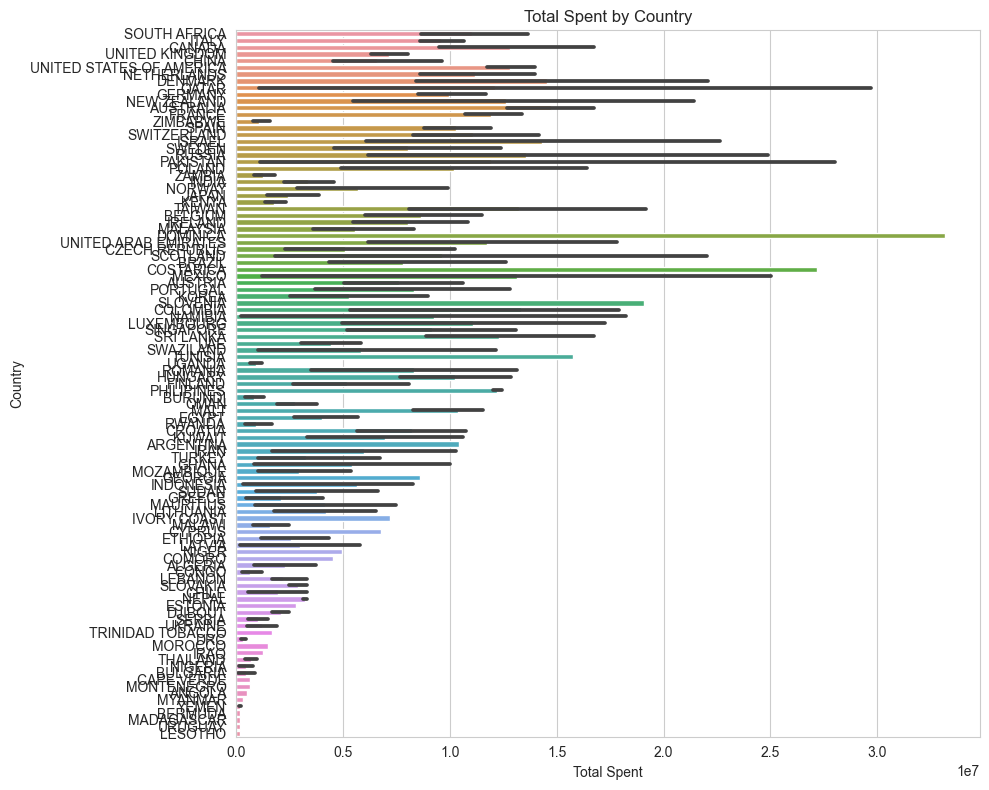

In [50]:
#for this exercise we will only deal with numeric variables

plt.figure(figsize=(10, 8))
sns.barplot(data=df_train.sort_values("total_cost", ascending=False), y="country", x="total_cost")
plt.xlabel("Total Spent")
plt.ylabel("Country")
plt.title("Total Spent by Country")
plt.tight_layout()
plt.show()

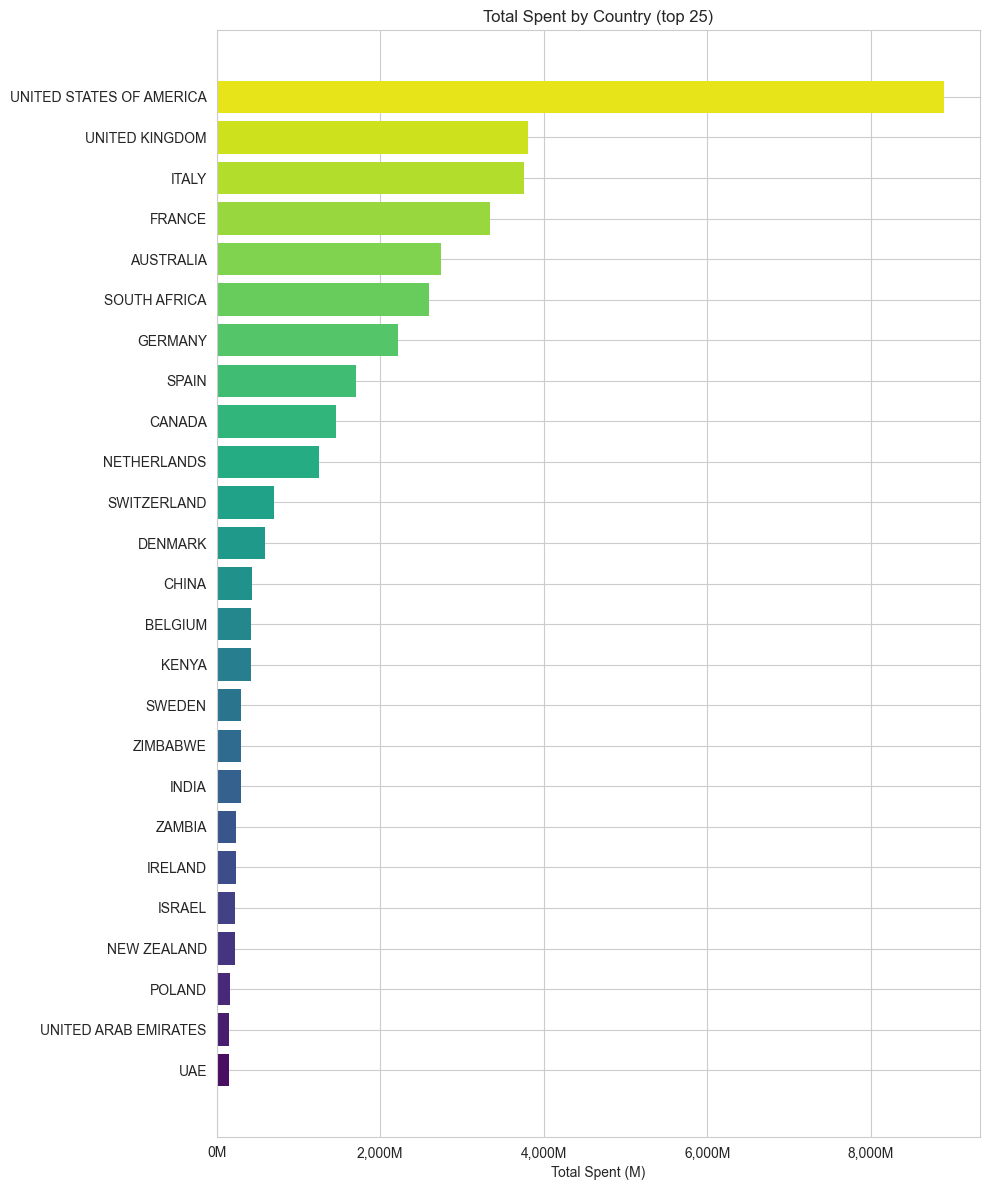

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# aggregate and sort
country_spend = df_train.groupby('country', as_index=False)['total_cost'].sum()
country_spend = country_spend.sort_values('total_cost', ascending=False)

# choose top N for clarity (e.g., top 25)
top_n = country_spend.head(25).iloc[::-1]  # reverse for horizontal plot

plt.figure(figsize=(10, 12))
sns.set_style('whitegrid')
palette = sns.color_palette('viridis', n_colors=len(top_n))

bars = plt.barh(top_n['country'], top_n['total_cost'], color=palette, edgecolor='none')

# format x-axis as millions
def millions(x, pos):
    return f'{x*1e-6:,.0f}M'  # convert to millions
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(millions))

plt.xlabel('Total Spent (M)')
plt.title('Total Spent by Country (top 25)')
plt.tight_layout()
plt.show()

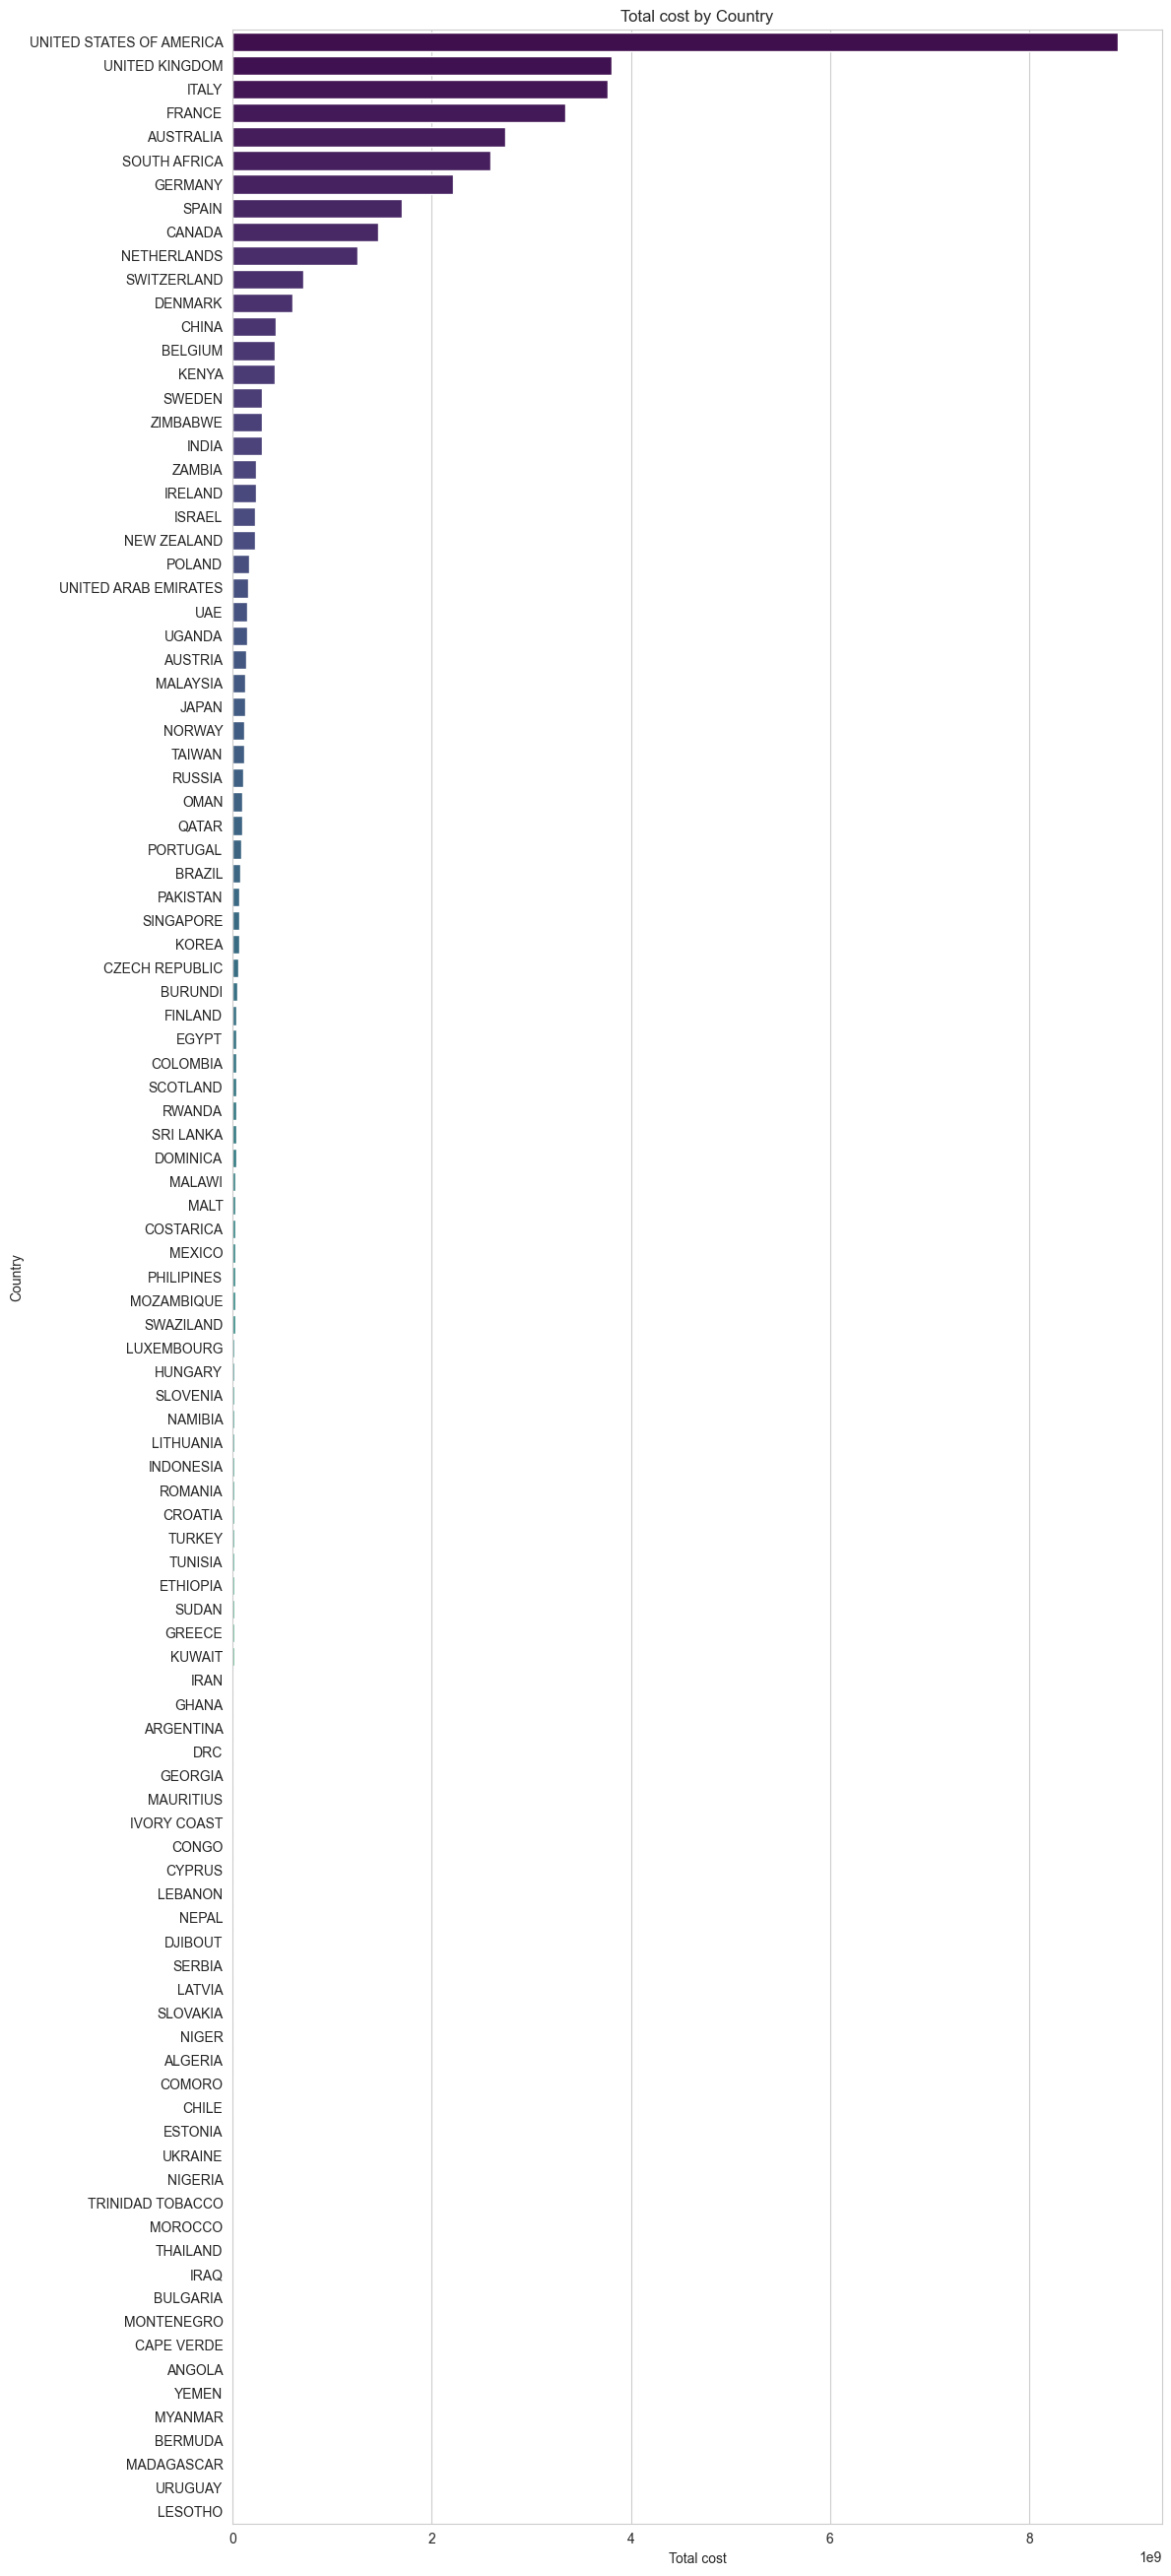

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

country_spend = (
    df_train.groupby("country", as_index=False)["total_cost"]
    .sum()
    .sort_values("total_cost", ascending=False)
)
plt.figure(figsize=(12, max(8, len(country_spend) * 0.25)))
sns.barplot(data=country_spend, y="country", x="total_cost", palette="viridis")
plt.xlabel("Total cost")
plt.ylabel("Country")
plt.title("Total cost by Country")
plt.tight_layout()
plt.show()

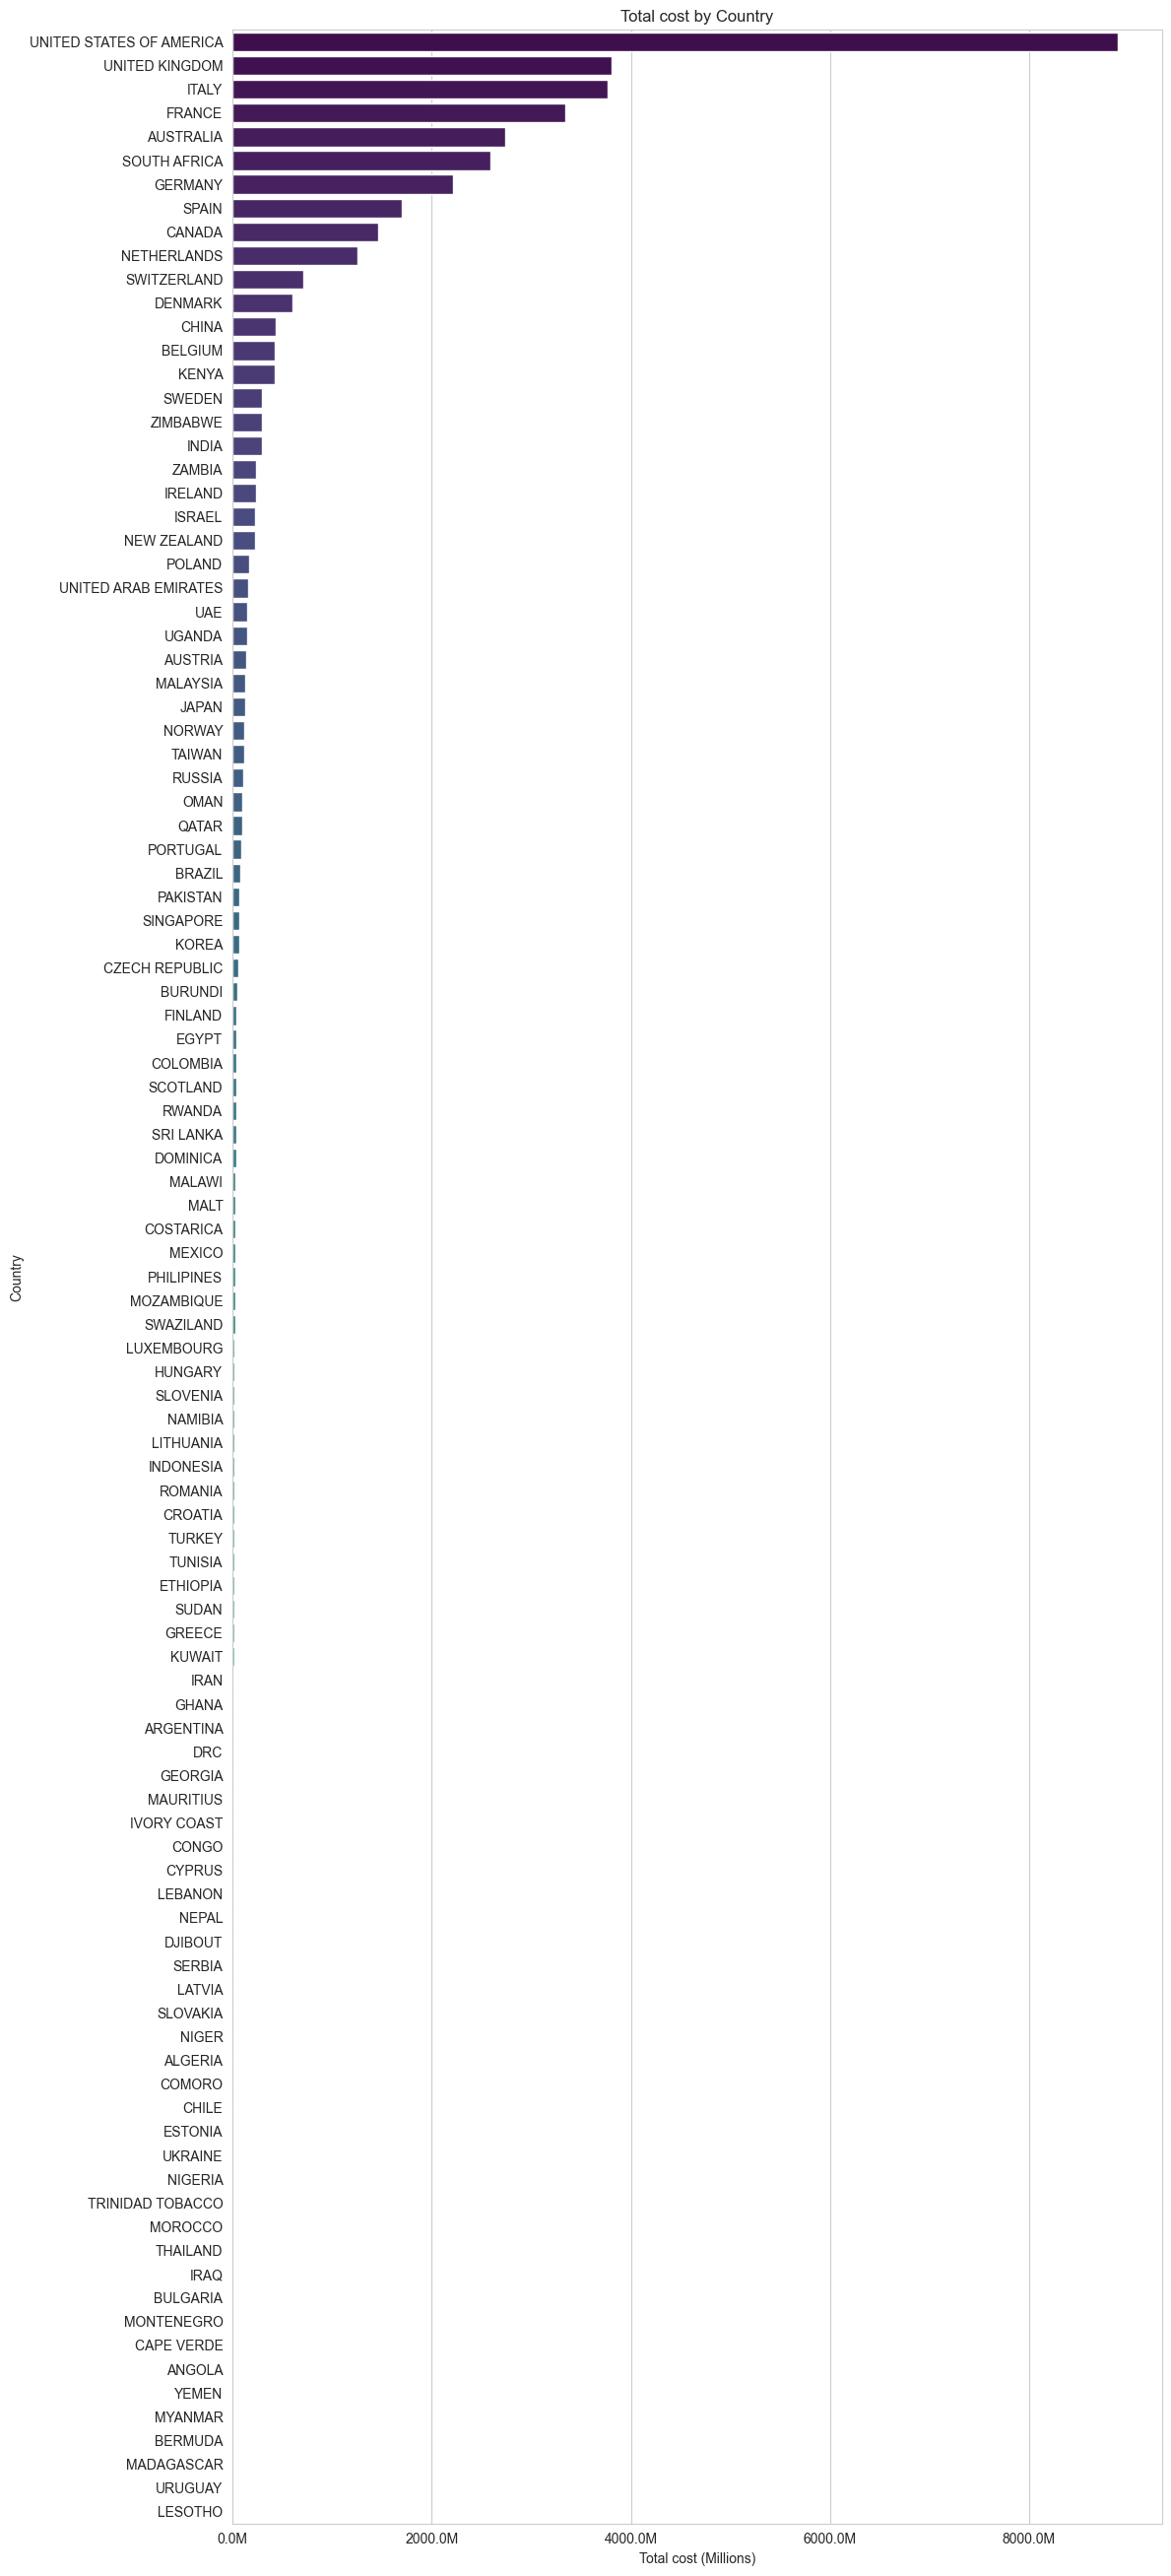

In [53]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

country_spend = (
    df_train.groupby("country", as_index=False)["total_cost"]
    .sum()
    .sort_values("total_cost", ascending=False)
)

plt.figure(figsize=(12, max(8, len(country_spend) * 0.25)))
ax = sns.barplot(data=country_spend, y="country", x="total_cost", palette="viridis")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x/1e6:.1f}M"))
plt.xlabel("Total cost (Millions)")
plt.ylabel("Country")
plt.title("Total cost by Country")
plt.tight_layout()
plt.show()

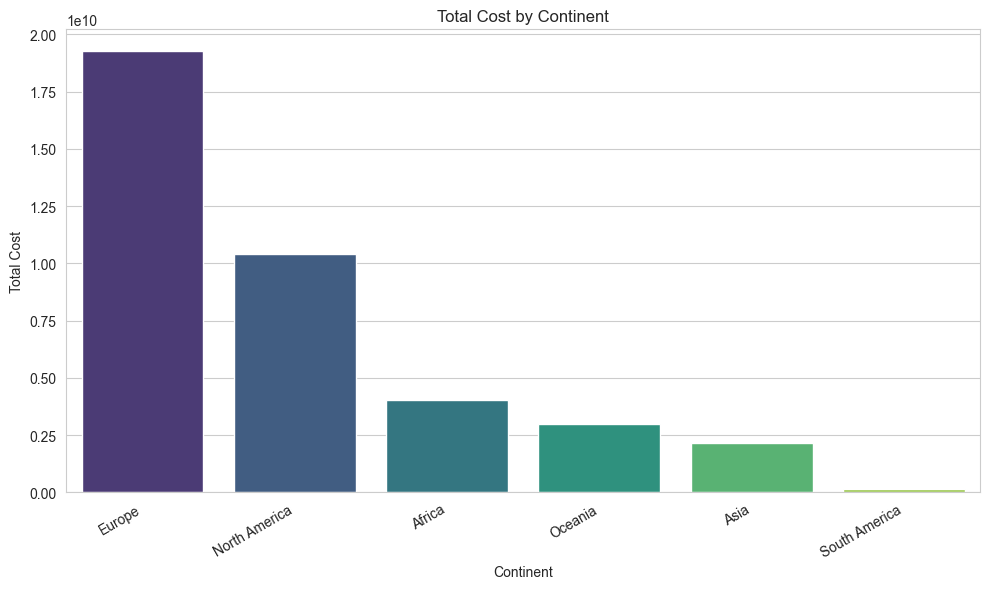

In [54]:
country_to_continent = {
    "UNITED STATES OF AMERICA": "North America",
    "UNITED KINGDOM": "Europe",
    "ITALY": "Europe",
    "FRANCE": "Europe",
    "AUSTRALIA": "Oceania",
    "SOUTH AFRICA": "Africa",
    "GERMANY": "Europe",
    "SPAIN": "Europe",
    "CANADA": "North America",
    "NETHERLANDS": "Europe",
    "SWITZERLAND": "Europe",
    "DENMARK": "Europe",
    "CHINA": "Asia",
    "BELGIUM": "Europe",
    "KENYA": "Africa",
    "SWEDEN": "Europe",
    "ZIMBABWE": "Africa",
    "INDIA": "Asia",
    "ZAMBIA": "Africa",
    "IRELAND": "Europe",
    "ISRAEL": "Asia",
    "NEW ZEALAND": "Oceania",
    "POLAND": "Europe",
    "UNITED ARAB EMIRATES": "Asia",
    "UAE": "Asia",
    "UGANDA": "Africa",
    "AUSTRIA": "Europe",
    "MALAYSIA": "Asia",
    "JAPAN": "Asia",
    "NORWAY": "Europe",
    "TAIWAN": "Asia",
    "RUSSIA": "Europe",
    "OMAN": "Asia",
    "QATAR": "Asia",
    "PORTUGAL": "Europe",
    "BRAZIL": "South America",
    "PAKISTAN": "Asia",
    "SINGAPORE": "Asia",
    "KOREA": "Asia",
    "SOUTH KOREA": "Asia",
    "CZECH REPUBLIC": "Europe",
    "BURUNDI": "Africa",
    "FINLAND": "Europe",
    "EGYPT": "Africa",
    "COLOMBIA": "South America",
    "SCOTLAND": "Europe",
    "RWANDA": "Africa",
    "SRI LANKA": "Asia",
    "DOMINICA": "North America",
    "MALAWI": "Africa",
    "MALTA": "Europe",
    "COSTA RICA": "North America",
    "MEXICO": "North America",
    "PHILIPPINES": "Asia",
    "MOZAMBIQUE": "Africa",
    "SWAZILAND": "Africa",
    "ESWATINI": "Africa",
    "LUXEMBOURG": "Europe",
    "HUNGARY": "Europe",
    "SLOVENIA": "Europe",
    "NAMIBIA": "Africa",
    "LITHUANIA": "Europe",
    "INDONESIA": "Asia",
    "ROMANIA": "Europe",
    "CROATIA": "Europe",
    "TURKEY": "Asia",
    "TUNISIA": "Africa",
    "ETHIOPIA": "Africa",
    "SUDAN": "Africa",
    "GREECE": "Europe",
    "KUWAIT": "Asia",
    "IRAN": "Asia",
    "GHANA": "Africa",
    "ARGENTINA": "South America",
    "DRC": "Africa",
    "GEORGIA": "Asia",
    "MAURITIUS": "Africa",
    "IVORY COAST": "Africa",
    "CONGO": "Africa",
    "CYPRUS": "Europe",
    "LEBANON": "Asia",
    "NEPAL": "Asia",
    "DJIBOUTI": "Africa",
    "SERBIA": "Europe",
    "LATVIA": "Europe",
    "SLOVAKIA": "Europe",
    "NIGER": "Africa",
    "ALGERIA": "Africa",
    "COMORO": "Africa",
    "CHILE": "South America",
    "ESTONIA": "Europe",
    "UKRAIN": "Europe",
    "UKRAINE": "Europe",
    "NIGERIA": "Africa",
    "TRINIDAD TOBAGO": "North America",
    "TRINIDAD AND TOBAGO": "North America",
    "MORROCO": "Africa",
    "MOROCCO": "Africa",
    "THAILAND": "Asia",
    "IRAQ": "Asia",
    "BURGARIA": "Europe",
    "BULGARIA": "Europe",
    "MONTENEGRO": "Europe",
    "CAPE VERDE": "Africa",
    "ANGOLA": "Africa",
    "YEMEN": "Asia",
    "MYANMAR": "Asia",
    "BERMUDA": "North America",
    "MADAGASCAR": "Africa",
    "URUGUAY": "South America",
    "LESOTHO": "Africa"
}
df_train["continent"] = df_train["country"].str.upper().map(country_to_continent)
continent_cost = (
    df_train.groupby("continent", as_index=False)["total_cost"]
    .sum()
    .sort_values("total_cost", ascending=False)
)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(data=continent_cost, x="continent", y="total_cost", palette="viridis")
plt.xticks(rotation=30, ha="right")
plt.title("Total Cost by Continent")
plt.xlabel("Continent")
plt.ylabel("Total Cost")
plt.tight_layout()
plt.show()

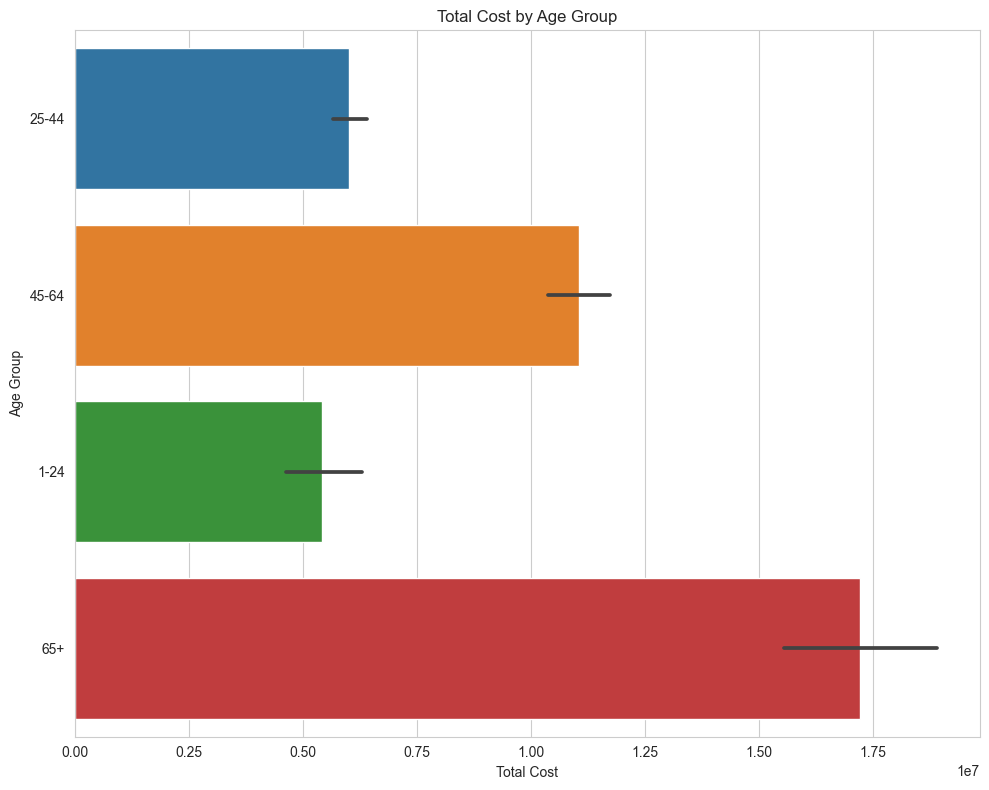

In [55]:
plt.figure(figsize=(10, 8))
sns.barplot(data=df_train.sort_values("total_cost", ascending=False), y="age_group", x="total_cost")
plt.xlabel("Total Cost")
plt.ylabel("Age Group")
plt.title("Total Cost by Age Group")
plt.tight_layout()
plt.show()

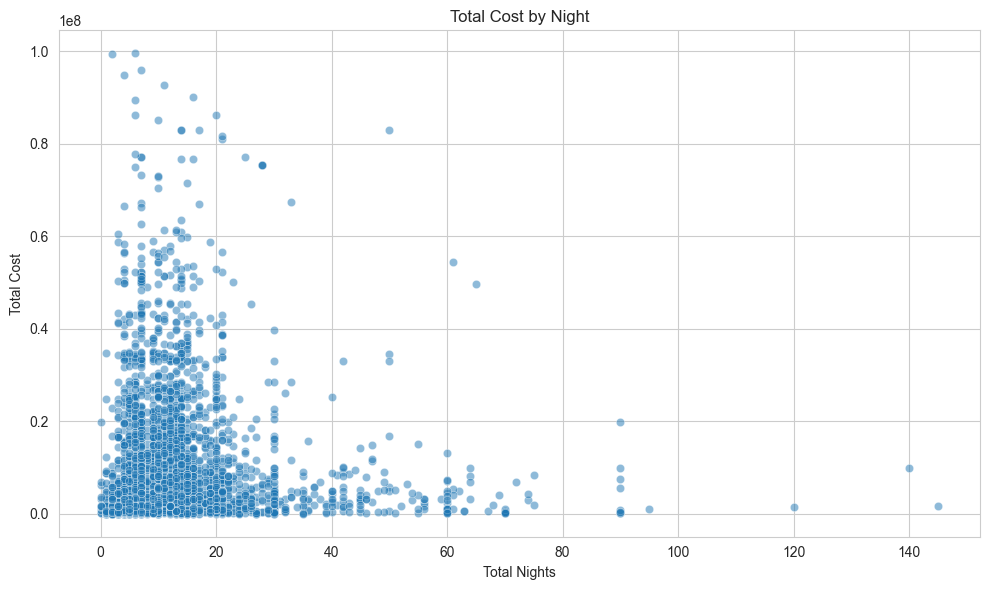

In [56]:
df_train["total_nights"] = df_train["night_mainland"] + df_train["night_zanzibar"]
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_train, x="total_nights", y="total_cost", alpha=0.5)
plt.xlabel("Total Nights")
plt.ylabel("Total Cost")
plt.title("Total Cost by Night")
plt.tight_layout()
plt.show()

In [46]:
df_train["total_nights"] = df_train["night_mainland"] + df_train["night_zanzibar"]

df_train["cost_per_night"] = df_train["total_cost"] / df_train["total_nights"]
print(df_train["cost_per_night"].mean())

inf


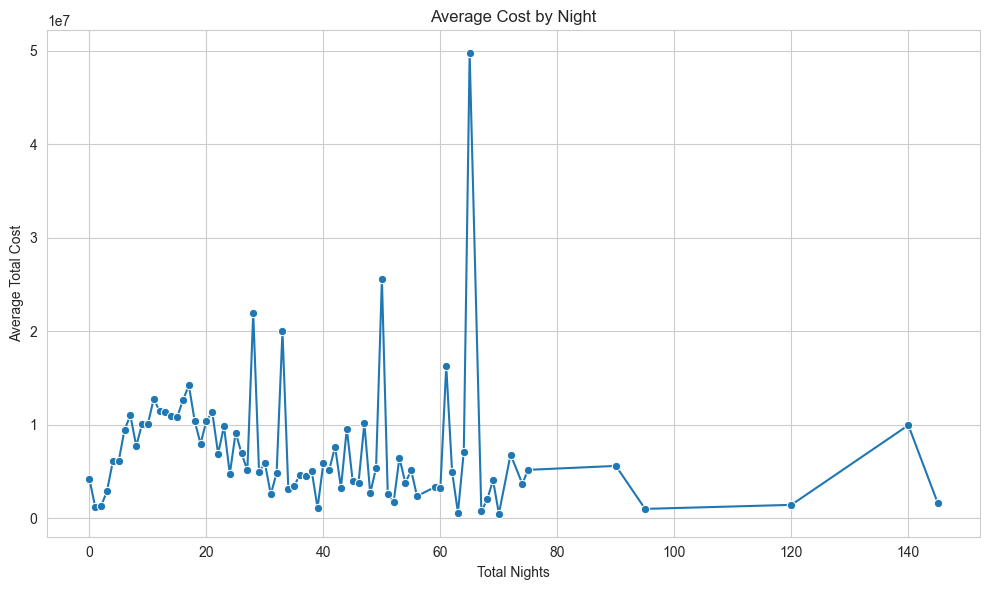

In [45]:
avg_cost_by_night = (
    df_train.groupby("total_nights", as_index=False)["total_cost"]
    .mean()
    .sort_values("total_nights")
)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(data=avg_cost_by_night, x="total_nights", y="total_cost", marker="o")
plt.xlabel("Total Nights")
plt.ylabel("Average Total Cost")
plt.title("Average Cost by Night")
plt.tight_layout()
plt.show()

In [47]:
df_train["travel_with"] = df_train["travel_with"].fillna("UNKNOWN")
df_train["most_impressing"] = df_train["most_impressing"].fillna("UNKNOWN")

df_train["total_female"] = df_train["total_female"].fillna(df_train["total_female"].median())
df_train["total_male"] = df_train["total_male"].fillna(df_train["total_male"].median())

In [48]:
df_train["total_people"] = df_train["total_female"] + df_train["total_male"]
df_train["total_nights"] = df_train["night_mainland"] + df_train["night_zanzibar"]
df_train["cost_per_night"] = df_train["total_cost"] / df_train["total_nights"].replace(0, pd.NA)

In [57]:
print(df_train["country"].value_counts().head(10))
print(df_train["purpose"].value_counts().head(10))
print(df_train["main_activity"].value_counts().head(10))

country
UNITED STATES OF AMERICA    695
UNITED KINGDOM              533
ITALY                       393
FRANCE                      280
ZIMBABWE                    274
SOUTH AFRICA                235
KENYA                       235
GERMANY                     223
ZAMBIA                      191
AUSTRALIA                   186
Name: count, dtype: int64
purpose
LEISURE AND HOLIDAYS              2840
BUSINESS                           671
VISITING FRIENDS AND RELATIVES     633
MEETINGS AND CONFERENCE            312
VOLUNTEERING                       138
OTHER                              128
SCIENTIFIC AND ACADEMIC             87
Name: count, dtype: int64
main_activity
WILDLIFE TOURISM            2259
BEACH TOURISM               1025
HUNTING TOURISM              457
CONFERENCE TOURISM           367
CULTURAL TOURISM             359
MOUNTAIN CLIMBING            234
BUSINESS                      58
BIRD WATCHING                 37
DIVING AND SPORT FISHING      13
Name: count, dtype: int64


## Group Analysis 

In [58]:
country_cost = (
    df_train.groupby("country", as_index=False)
    .agg(avg_cost=("total_cost", "mean"), median_cost=("total_cost", "median"), trips=("total_cost", "size"))
    .sort_values("avg_cost", ascending=False)
)

purpose_cost = (
    df_train.groupby("purpose", as_index=False)
    .agg(avg_cost=("total_cost", "mean"), median_cost=("total_cost", "median"), trips=("total_cost", "size"))
    .sort_values("avg_cost", ascending=False)
)

activity_cost = (
    df_train.groupby("main_activity", as_index=False)
    .agg(avg_cost=("total_cost", "mean"), median_cost=("total_cost", "median"), trips=("total_cost", "size"))
    .sort_values("avg_cost", ascending=False)
)

print(country_cost.head(10))
print(purpose_cost.head(10))
print(activity_cost.head(10))

      country      avg_cost  median_cost  trips
23   DOMINICA  3.315000e+07   33150000.0      1
17  COSTARICA  2.718300e+07   27183000.0      1
82   SLOVENIA  1.906237e+07   19062372.0      1
93    TUNISIA  1.574625e+07   15746250.0      1
3   AUSTRALIA  1.474802e+07    9903562.5    186
21    DENMARK  1.456879e+07    3397875.0     41
40     ISRAEL  1.430542e+07    4508400.0     16
76     RUSSIA  1.358321e+07    8619000.0      8
14   COLOMBIA  1.331525e+07   15580500.0      3
90     TAIWAN  1.321396e+07    9945000.0      9
                          purpose      avg_cost  median_cost  trips
1            LEISURE AND HOLIDAYS  1.195114e+07    7293000.0   2840
4         SCIENTIFIC AND ACADEMIC  4.031990e+06    1160250.0     87
6                    VOLUNTEERING  3.950565e+06    2652000.0    138
5  VISITING FRIENDS AND RELATIVES  3.190776e+06     828750.0    633
2         MEETINGS AND CONFERENCE  2.453004e+06    1160250.0    312
0                        BUSINESS  1.782438e+06     680799.0    

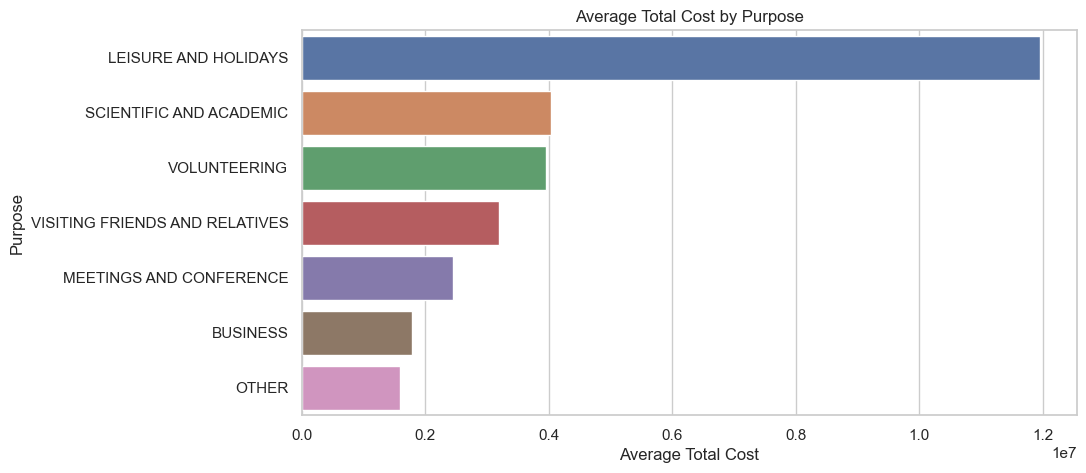

In [65]:
purpose_cost = (
    df_train.groupby("purpose", as_index=False)["total_cost"]
    .mean()
    .sort_values("total_cost", ascending=False)
)

plt.figure(figsize=(10,5))
sns.barplot(data=purpose_cost, y="purpose", x="total_cost")
plt.title("Average Total Cost by Purpose")
plt.xlabel("Average Total Cost")
plt.ylabel("Purpose")
plt.show()

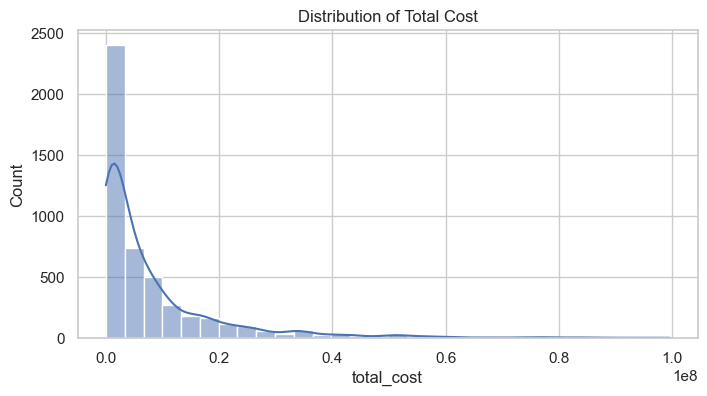

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.figure(figsize=(8,4))
sns.histplot(df_train["total_cost"], bins=30, kde=True)
plt.title("Distribution of Total Cost")
plt.show()

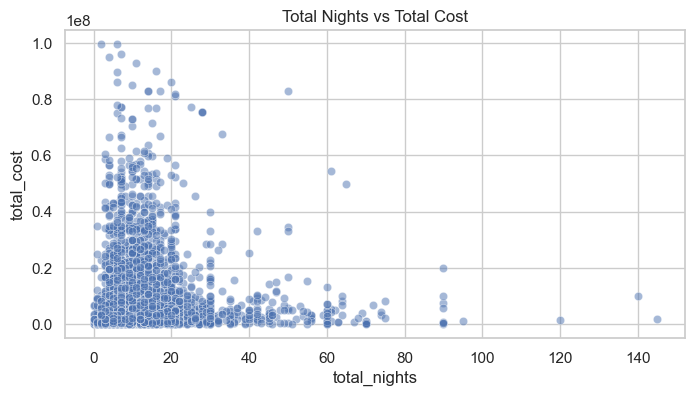

In [62]:
plt.figure(figsize=(8,4))
sns.scatterplot(data=df_train, x="total_nights", y="total_cost", alpha=0.5)
plt.title("Total Nights vs Total Cost")
plt.show()

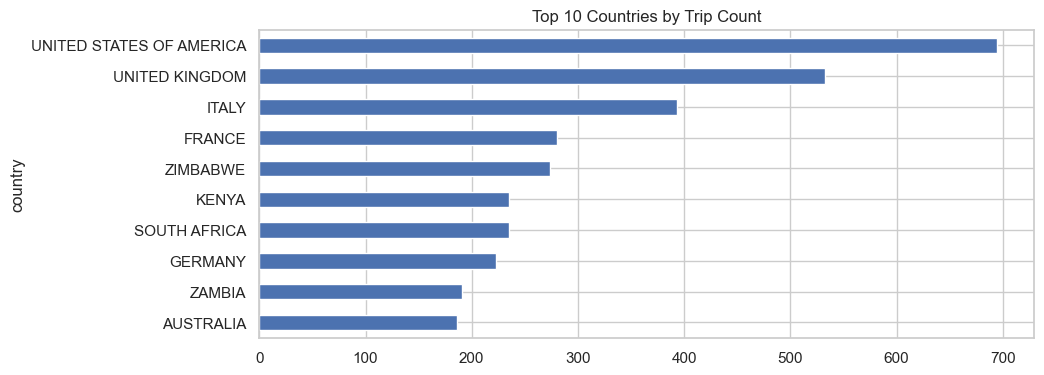

In [61]:
top_countries = df_train["country"].value_counts().head(10)

plt.figure(figsize=(10,4))
top_countries.sort_values().plot(kind="barh")
plt.title("Top 10 Countries by Trip Count")
plt.show()

In [63]:
print(df_train[["total_cost", "total_nights", "total_people"]].corr(numeric_only=True))

              total_cost  total_nights  total_people
total_cost      1.000000      0.076723      0.278266
total_nights    0.076723      1.000000      0.040929
total_people    0.278266      0.040929      1.000000


## Splitting data for base model testing LG

In [81]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

target_col = "total_cost"

drop_cols = [target_col]
if "tour_id" in df_train.columns:
    drop_cols.append("tour_id")

X = df_train.drop(columns=drop_cols)
y = df_train[target_col]

X = pd.get_dummies(X, drop_first=True)

X = X.replace([np.inf, -np.inf], np.nan).dropna()
y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.4f}")

MAE: 5409269.77
RMSE: 8901438.70
R2: 0.4388


#How to read it
#MAE: 5,409,269.77 means your predictions are off by about 5.4 million on average, in the same unit as #total_cost.

#RMSE: 8,901,438.70 is larger than MAE, so there are some larger mistakes pulling the error up.

#R2: 0.4388 is moderate for a first linear model, but clearly not strong enough yet.

In [71]:
df_encoded = pd.get_dummies(df_train, columns=categorical_cols, drop_first=True)
y = df_encoded["total_cost"]
X = df_encoded.drop(columns=["total_cost"])